# Notebook 06 — Evaluation & Interpretation
Load the saved best models from notebooks 04 and 05.
Produce: predicted vs actual, residual plots, SHAP values, and the final comparison table.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import sys
sys.path.append('../')
from utils import regression_metrics
sns.set_theme(style='whitegrid')

PROCESSED = '../data/processed/'

with open(PROCESSED + 'best_disaster_model.pkl', 'rb') as f:
    d_bundle = pickle.load(f)

with open(PROCESSED + 'best_project_model.pkl', 'rb') as f:
    p_bundle = pickle.load(f)

print('Disaster model:', d_bundle['model_name'])
print('Project  model:', p_bundle['model_name'])


Disaster model: Random Forest
Project  model: Ridge Regression


## 6.1 Predicted vs Actual — Both Models


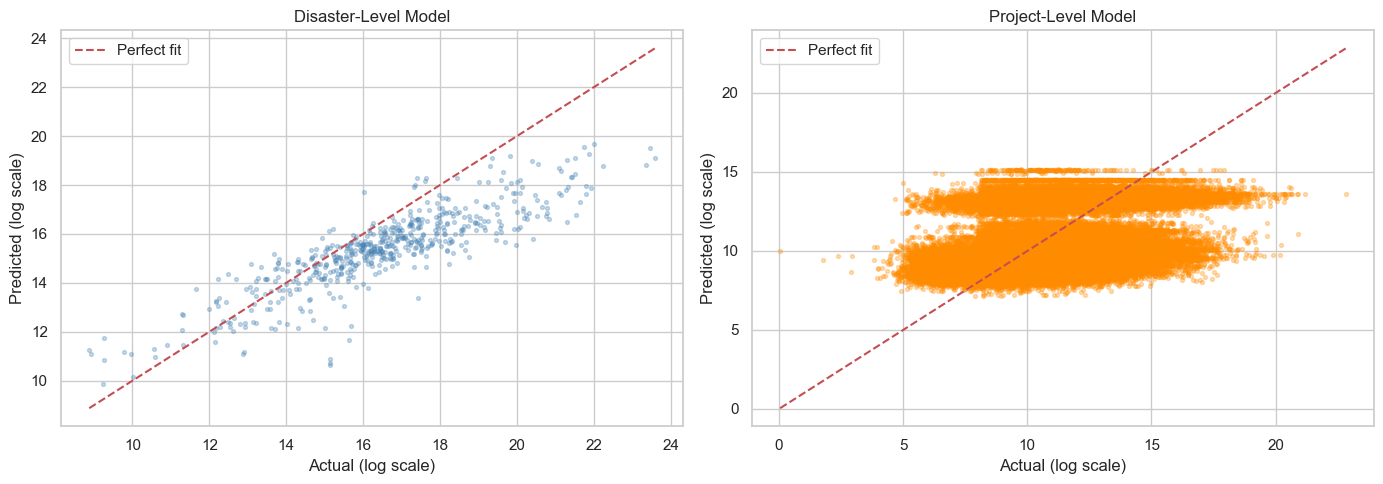

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, bundle, title, color in [
    (axes[0], d_bundle, 'Disaster-Level Model', 'steelblue'),
    (axes[1], p_bundle, 'Project-Level Model',  'darkorange')
]:
    y_true = bundle['y_test']
    preds  = bundle['preds']
    ax.scatter(y_true, preds, alpha=0.3, s=8, color=color)
    lo = min(y_true.min(), preds.min())
    hi = max(y_true.max(), preds.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Perfect fit')
    ax.set_xlabel('Actual (log scale)')
    ax.set_ylabel('Predicted (log scale)')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig(PROCESSED + 'predicted_vs_actual.png', dpi=150)
plt.show()


## 6.2 Residual Plots
Residuals should be randomly scattered around 0. Any pattern = systematic bias.


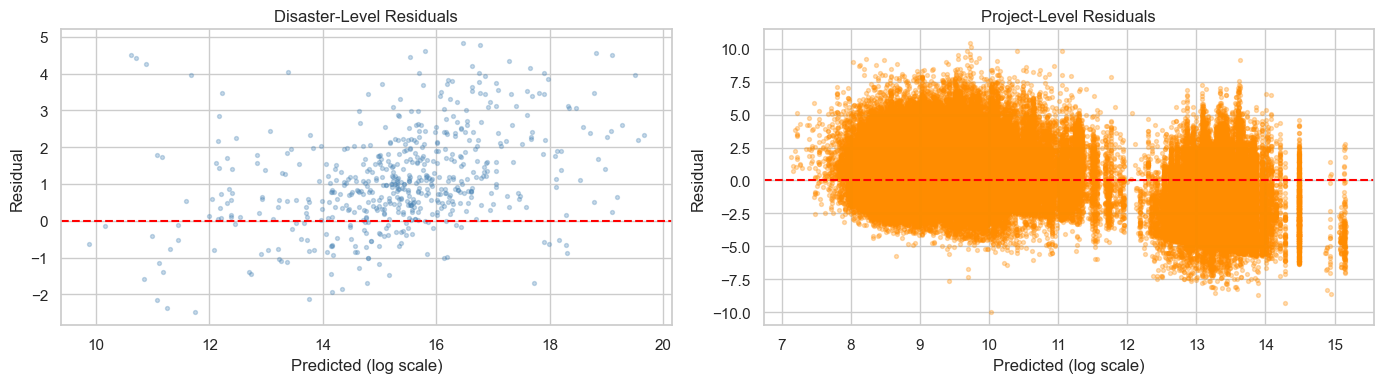

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, bundle, title, color in [
    (axes[0], d_bundle, 'Disaster-Level Residuals', 'steelblue'),
    (axes[1], p_bundle, 'Project-Level Residuals',  'darkorange')
]:
    residuals = np.array(bundle['y_test']) - bundle['preds']
    ax.scatter(bundle['preds'], residuals, alpha=0.3, s=8, color=color)
    ax.axhline(0, color='red', linestyle='--', lw=1.5)
    ax.set_xlabel('Predicted (log scale)')
    ax.set_ylabel('Residual')
    ax.set_title(title)

plt.tight_layout()
plt.savefig(PROCESSED + 'residual_plots.png', dpi=150)
plt.show()


## 6.3 Final Metrics Comparison Table


In [4]:
rows = []
for bundle, level in [(d_bundle, 'Disaster-Level'), (p_bundle, 'Project-Level')]:
    m = regression_metrics(bundle['y_test'].values, bundle['preds'],
                           label=f"{bundle['model_name']} ({level})")
    m['Level'] = level
    rows.append(m)

comparison = pd.DataFrame(rows)[['label', 'Level', 'MAE', 'RMSE', 'R2', 'MAPE']]
comparison = comparison.rename(columns={'label': 'Model'})
comparison



  Random Forest (Disaster-Level)
  MAE  :     1.3660
  RMSE :     1.7262
  R²   :     0.4939
  MAPE :      7.94%

  Ridge Regression (Project-Level)
  MAE  :     1.8188
  RMSE :     2.2921
  R²   :    -0.2988
  MAPE :     17.24%


,Model,Level,MAE,RMSE,R2,MAPE
0,Random Forest (Disaster-Level),Disaster-Level,1.365988,1.726216,0.493919,7.941926
1,Ridge Regression (Project-Level),Project-Level,1.818770,2.292087,-0.298842,17.236234


## 6.4 SHAP Values — Why Does the Model Predict What It Predicts?
SHAP explains individual predictions — which features push a value up or down.
Install with: `pip install shap`


In [9]:
try:
    import shap

    bundle   = d_bundle  # change to p_bundle for project-level
    pipeline = bundle['pipeline']
    X_test   = bundle['X_test']

    # Transform test data through the preprocessing steps
    X_transformed = pipeline.named_steps['pre'].transform(X_test)

    # Build feature names
    pre = pipeline.named_steps['pre']
    ohe_names  = pre.transformers_[0][1].named_steps['ohe'].get_feature_names_out(bundle['cat_features'])
    all_names  = list(ohe_names) + bundle['num_features']

    rf_model = pipeline.named_steps['model']
    explainer = shap.TreeExplainer(rf_model)

    # Sample 500 rows for speed
    idx = np.random.choice(len(X_transformed), size=min(500, len(X_transformed)), replace=False)
    shap_values = explainer.shap_values(X_transformed[idx])

    shap.summary_plot(shap_values, X_transformed[idx], feature_names=all_names,
                      max_display=15, show=True)

except ImportError:
    print('shap not installed. Run: pip install shap')


shap not installed. Run: pip install shap


## 6.5 Critical Reflection

### What the model does well
- Captures broad patterns: incident type, state, season, and county demographics explain
  a meaningful portion of variance at the disaster level.
- The disaster-level model is more reliable than the project-level model because
  aggregation smooths noise — consistent with our design intent.

### Limitations
- **Black swan events**: Katrina, Sandy, Harvey are statistical outliers. No model trained
  on historical averages can reliably predict once-in-a-generation disasters.
- **Policy changes**: FEMA cost-share rules and reimbursement policies have changed over
  the dataset's timespan — the model may not reflect current rules.
- **Geography mismatch**: Some PA projects span multiple counties; we assigned one FIPS
  per project, which may misrepresent the affected area.

### Bias Concerns
- States with more disasters have more training examples → better predictions.
  Rural, lower-capacity counties may be systematically under-predicted.
- Rare incident types (chemical spills, dam failures) have too few examples
  for the model to generalise from.

### Future Work
- **NOAA Storm Events** (wind speed, precipitation) for physical disaster intensity.
- **Satellite imagery** for damage extent estimation (long-term research direction).
- **XGBoost / LightGBM** tuning for potentially higher R².
- **Real-time pipeline**: connect to FEMA OpenFEMA API to predict on newly declared disasters.
